In [ ]:
import os
import sys
import joblib
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [47]:
sys.path.append('../')
CLASSES = {'vio': 0, 'pia': 1, 'cla': 2}
BASE_PATH = os.path.abspath("../")

from utils.extrair_atributos import extrair_atributos

In [48]:
model  = joblib.load(BASE_PATH + "/resultados/" + "vetores_suporte/" + "svm_instrumentos.pkl")
scaler = joblib.load(BASE_PATH + "/resultados/" + "vetores_suporte/" + "scaler_instrumentos.pkl")

C:\Users\kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\kamil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [49]:
path = BASE_PATH + "/datasets/new_audio/vio_seg002.wav"

In [50]:
y, _ = librosa.load(path)
features = np.array(extrair_atributos(y)).reshape(1, -1)
features = scaler.transform(features)
pred = model.predict(features)[0]

Exemplo

In [51]:
labels = {v: k for k, v in CLASSES.items()}

print("Intrumento Real: ", os.path.basename(path).split("_")[0])
print("Intrumento Predito: ", labels[int(pred)])

Intrumento Real:  vio
Intrumento Predito:  vio


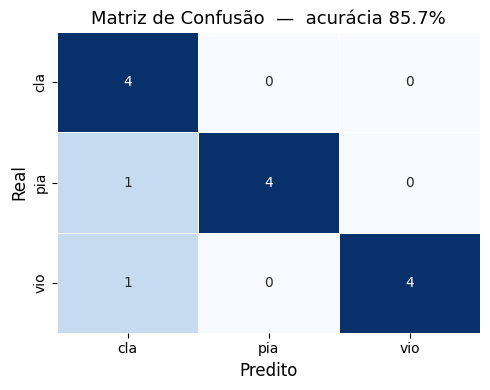

In [52]:
datasets  = os.path.join(BASE_PATH, "datasets", "new_audio")
classes   = ["cla", "pia", "vio"]

y_true, y_pred = [], []

for arquivo in sorted(os.listdir(datasets)):
    if not arquivo.endswith(".wav"):
        continue

    verdadeiro = arquivo.split("_")[0]
    caminho    = os.path.join(datasets, arquivo)

    y, sr    = librosa.load(caminho, sr=22050, mono=True)
    features = np.array(extrair_atributos(y)).reshape(1, -1)
    features = scaler.transform(features)

    pred = model.predict(features)[0]

    y_true.append(verdadeiro)
    y_pred.append(labels[pred])

cm = confusion_matrix(y_true, y_pred, labels=classes)
acuracia = cm.diagonal().sum() / cm.sum()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=classes, yticklabels=classes,
    linewidths=0.5, linecolor="white",
    cbar=False, ax=ax,
)
ax.set_xlabel("Predito", fontsize=12)
ax.set_ylabel("Real", fontsize=12)
ax.set_title(f"Matriz de Confusão  —  acurácia {acuracia:.1%}", fontsize=13)
plt.tight_layout()
plt.show()
